In [63]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import arviz as az
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.linear_model import LassoCV, Lasso
from sklearn.model_selection import KFold, cross_val_score



gdf = gpd.read_file(r"../data/updated_data.geojson")

#fem_house_rate has been deleted because it is obvious that if fem_house_rate is high, ratio_fem_mal will be low
col_to_del_linear_model=['geo_point_2d','urban_type','private_coverage','empl_gap']

gdf.drop(columns=col_to_del_linear_model,inplace=True)

#there is one missing value on ecec_diffusion variable
gdf["ecec_diffusion"] = gdf["ecec_diffusion"].fillna(gdf["ecec_diffusion"].median())



In [64]:


X=gdf.select_dtypes(include='number').drop(columns=['fem_empl_rate','mal_empl_rate'])
y=gdf['fem_empl_rate']
offset=gdf['mal_empl_rate']

# Correlation Part

In [65]:
import numpy as np

#THRESHOLD=0.9
col_to_drop=['empl_rate', 'inact_rate', 'other_per_capita_expenditure', 'adj_net_migration_rate','part_rate','unempl_rate','male_edu_rate','fem_house_rate']

X.drop(columns=col_to_drop,inplace=True)

corr_matrix=X.corr()

upper_matrix = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

stacked=upper_matrix.stack()
best_pair = stacked.abs().idxmax()
best_corr_value = stacked.loc[best_pair]

print('best_pair',best_pair,'best_corr_value',best_corr_value)


best_pair ('fertility_rate', 'ageing_index') best_corr_value -0.8725350233934767


In [66]:


selected_covariates=X.columns

X = X.to_numpy()
y = y.to_numpy()/100
offset=offset.to_numpy()/100


# standardize predictors and the target
X_scaler = StandardScaler()
X_scaled = X_scaler.fit_transform(X)



y_logit = np.log(y/(1-y)) 
logit_offset=np.log(offset/(1-offset))

y_with_offset = y_logit - logit_offset


n_obs, n_feat = X_scaled.shape
print(f"\nNumber of observations: {n_obs}, number of predictors: {n_feat}")



Number of observations: 107, number of predictors: 37


# Frequentist Lasso (Credits : Chi)

Best alpha found: 0.0202

Mean CV R²: 0.411 ± 0.299
Mean CV MSE: 0.027 ± 0.017


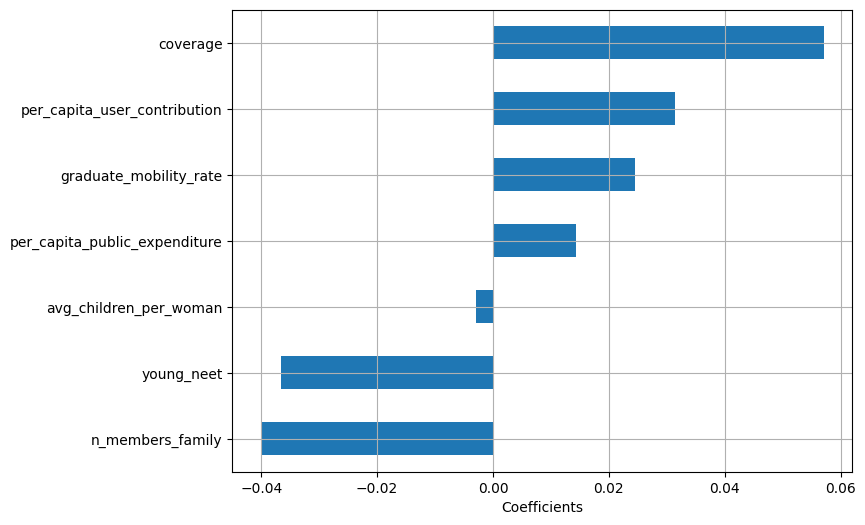

In [67]:


cv = KFold(n_splits=10, shuffle=True, random_state=42)
lasso_cv = LassoCV(cv=cv, random_state=42, max_iter=10000)
lasso_cv.fit(X_scaled, y_with_offset)

print(f"Best alpha found: {lasso_cv.alpha_:.4f}")

lasso_final = Lasso(alpha=lasso_cv.alpha_)
lasso_final.fit(X_scaled, y_with_offset)

coef = pd.Series(lasso_final.coef_, index=selected_covariates)
nonzero_coef = coef[coef != 0].sort_values(ascending=False)
# print("\nNon-zero coefficients (variables selected by Lasso):")
# print(nonzero_coef)

r2_scores = cross_val_score(lasso_final, X_scaled, y_with_offset, cv=cv, scoring='r2')
mse_scores = -cross_val_score(lasso_final, X_scaled, y_with_offset, cv=cv, scoring='neg_mean_squared_error')
print(f"\nMean CV R²: {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")
print(f"Mean CV MSE: {np.mean(mse_scores):.3f} ± {np.std(mse_scores):.3f}")

plt.figure(figsize=(8,6))
nonzero_coef.sort_values().plot(kind='barh')
# plt.title('Lasso-selected variables influencing ratio female/male employment rate')
plt.xlabel('Coefficients')
plt.grid(True)
plt.show()

/var/folders/y9/rry2kyrd4wlb4xwqx57mrs540000gn/T/ipykernel_79953/2468796985.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


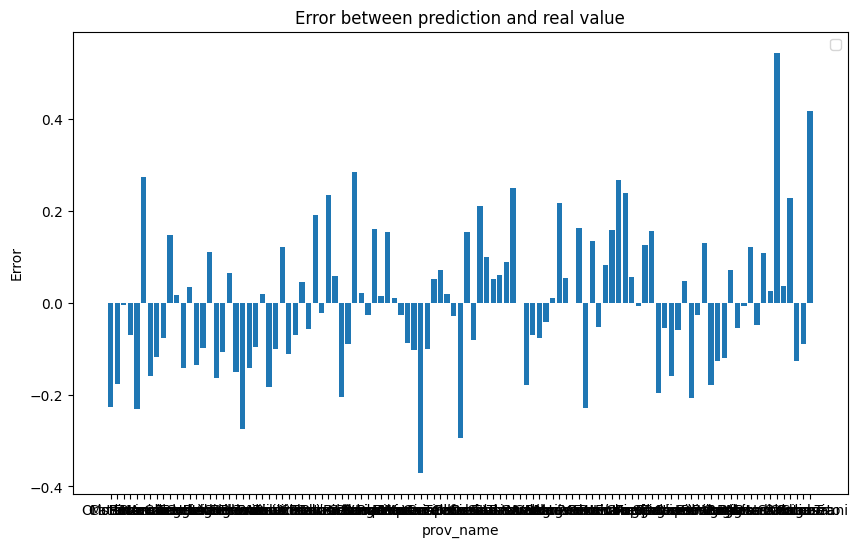

In [68]:
y_pred = lasso_final.predict(X_scaled)

Error=y_pred-y_with_offset


plt.figure(figsize=(10,6))
plt.bar(gdf["prov_name"],Error)
plt.xlabel("prov_name")
plt.ylabel("Error")
plt.title("Error between prediction and real value")
plt.legend()
plt.show()

# Bayes Lasso (Credits : Leo)

In [69]:
with pm.Model() as bl_model:
    X_data = pm.Data("X_data", X_scaled)
    y_data = pm.Data("y_data", y_logit)

    lambda_ = pm.Gamma("lambda", alpha=0.1, beta=0.1)
    sigma = pm.HalfNormal("sigma", sigma=1.0)


    beta = pm.Laplace(
        "beta",
        mu=0.0,
        b=sigma / lambda_,
        shape=n_feat
    )

    intercept = pm.Laplace("alpha", mu=0.0, b=sigma / lambda_)
    # intercept = pm.Normal("alpha", mu=0.0, sigma=5.0)

    offset_values = pm.Data("offset", logit_offset)


    mu = pm.math.dot(X_data, beta) + intercept+ offset_values


    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_data)


    trace = pm.sample(
        draws=2000,
        tune=2000,
        target_accept=0.9,
        return_inferencedata=True,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lambda, sigma, beta, alpha]


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/rich/live.py:256: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 51 seconds.


In [70]:
summary_beta = az.summary(trace, var_names=["beta"], hdi_prob=0.95)

summary_beta.index = selected_covariates

summary_beta["contains_zero"] = (
    (summary_beta["hdi_2.5%"] <= 0) &
    (summary_beta["hdi_97.5%"] >= 0)
)

# summary_beta["contains_zero"] = (
#     (summary_beta["hdi_5%"] <= 0) &
#     (summary_beta["hdi_95%"] >= 0)
# )

summary_beta = summary_beta.sort_values("mean", key=np.abs, ascending=False)

print(summary_beta[["mean", "hdi_2.5%", "hdi_97.5%", "contains_zero"]])
# print(summary_beta[["mean", "hdi_5%", "hdi_95%", "contains_zero"]])


                                     mean  hdi_2.5%  hdi_97.5%  contains_zero
coverage                            0.053    -0.004      0.106           True
young_neet                         -0.039    -0.102      0.015           True
avg_children_per_woman             -0.036    -0.107      0.021           True
graduate_mobility_rate              0.035    -0.038      0.118           True
n_members_family                   -0.033    -0.101      0.022           True
ecec_diffusion                     -0.033    -0.076      0.009           True
per_capita_user_contribution        0.031    -0.029      0.092           True
per_capita_public_expenditure       0.026    -0.031      0.090           True
n_self_empl                        -0.018    -0.056      0.020           True
fertility_rate                      0.016    -0.051      0.108           True
empl_growth                         0.013    -0.019      0.045           True
ecec_participation                  0.013    -0.051      0.084  

/var/folders/y9/rry2kyrd4wlb4xwqx57mrs540000gn/T/ipykernel_79953/1014072038.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


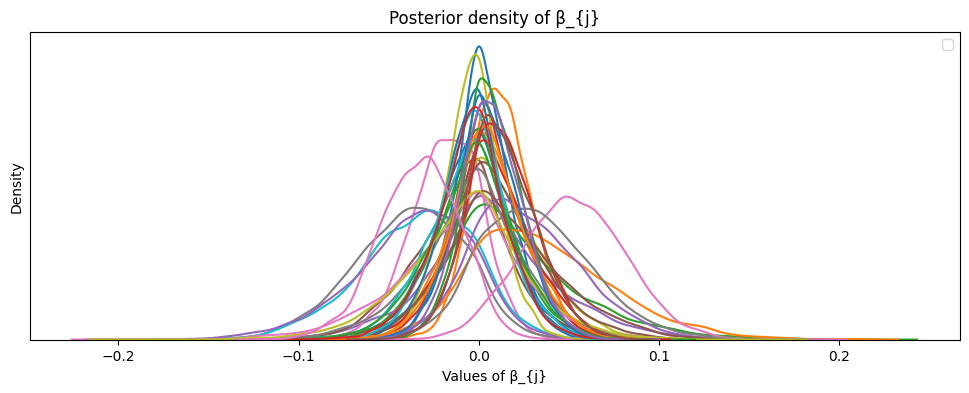

In [71]:


beta_samples = trace.posterior["beta"].stack(samples=("chain", "draw")).values

plt.figure(figsize=(12,4))

for i in range(beta_samples.shape[0]):
    # if (selected_covariates[i] in ['empl_rate','coverage','ratio_edu_rate','n_members_family','graduate_mobility_rate']):
    #     sns.kdeplot(beta_samples[i, :],label=selected_covariates[i])
    # else:
        sns.kdeplot(beta_samples[i, :])

plt.legend()
plt.title("Posterior density of β_{j}")
plt.xlabel("Values of β_{j}")
plt.yticks([])     
plt.gca().tick_params(axis='y', length=0)

plt.show()


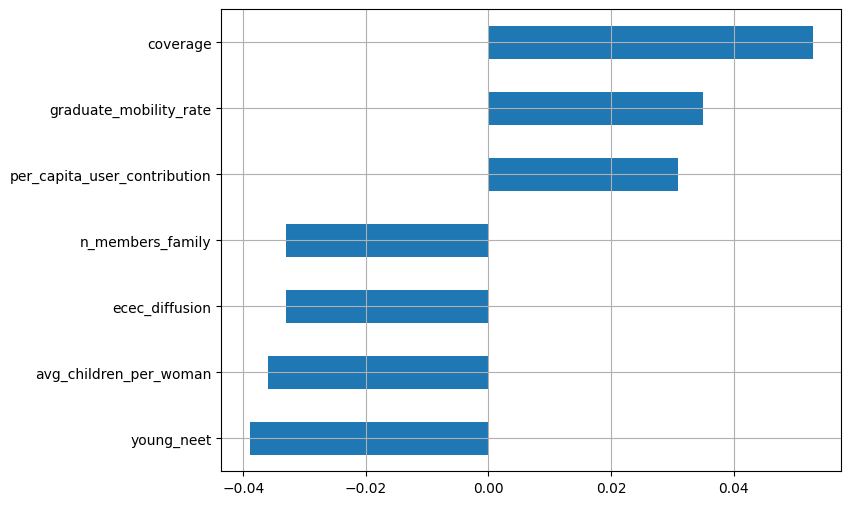

In [72]:
important_covariates=summary_beta[summary_beta["mean"].abs()>0.027]['mean']

plt.figure(figsize=(8,6))
important_covariates.sort_values().plot(kind='barh')
plt.grid(True)
plt.show()